In [2]:
from sklearn import datasets
wine = datasets.load_wine()
print(wine.keys())

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names'])


In [4]:
from sklearn.model_selection import train_test_split
X=wine.data[:,:2]
print(X.shape)



(178, 2)


In [25]:
# CLUSTERING with KMeans
from sklearn.cluster import KMeans
# create KMeans model (we choose number of clusters = 3 because wine has 3 classes)
kmeans = KMeans(n_clusters=3, random_state=22, n_init=10)
kmeans.fit(X)
cluster_labels = kmeans.labels_
print(f"Cluster labels: {cluster_labels}")
# Calculate score
from sklearn.metrics import silhouette_score
score = silhouette_score(X, cluster_labels)
print(score)
print(f"KMeans - Inertia: {kmeans.inertia_:.2f}")
# Predict new samples
new_samples = X[:5]
predictions = kmeans.predict(new_samples)
print(f"Predicted clusters for first 5 samples: {predictions}")

Cluster labels: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 1 0 1 0 1 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 2 2 2 0 2 2 2 2 2 0 2 2 0 0 0
 2 2 2 2 2 1 2 2 2 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 1 2 2 2 2 2 2 2 2 2 2 1
 2 2 2 2 2 2 2 1 1 2 2 1 1 1 2 2 2 2 1 2 1 2 1 2 2 1 1 1 1 1 0 1 1 1 1 1 1
 1 1 1 2 0 1 2 1 1 1 0 0 1 1 1 1 0 1 1 1 0 1 1 2 0 1 1 1 0 1]
0.45082007409392044
KMeans - Inertia: 107.51
Predicted clusters for first 5 samples: [0 0 0 0 0]


In [26]:
# DIMENSIONALITY REDUCTION with PCA
from sklearn.decomposition import PCA
X=wine.data[:,:3]
print(X.shape)
pca_model = PCA(n_components=3, random_state=22)
X_reduced = pca_model.fit_transform(X)
print(f"\nOriginal shape: {X.shape}")
print(f"Reduced shape: {X_reduced.shape}")
print(f"Explained variance ratio: {pca_model.explained_variance_ratio_}")
print(f"Total variance explained: {sum(pca_model.explained_variance_ratio_):.2%}")

(178, 3)

Original shape: (178, 3)
Reduced shape: (178, 3)
Explained variance ratio: [0.63707131 0.32767804 0.03525065]
Total variance explained: 100.00%


In [27]:
# ANOMALY DETECTION with IsolationForest
from sklearn.ensemble import IsolationForest
isoforest_model = IsolationForest(contamination=0.05, random_state=22)
outliers = isoforest_model.fit_predict(X)

# -1 = outlier, 1 = inlier
n_outliers = sum(outliers == -1)
print(f"Number of outliers detected: {n_outliers}")
print(f"Outlier ratio: {n_outliers/len(X):.2%}")

Number of outliers detected: 9
Outlier ratio: 5.06%


In [28]:
# CLUSTERING with DBSCAN
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

# Scale the data 
scaler = StandardScaler()
X_scaled = scaler.fit(X)
# Apply DBScan
dbscan_model = DBSCAN(eps=2, min_samples=5)
dbscan_labels = dbscan_model.fit_predict(X)
n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print(f"\nDBSCAN Clustering:")
print(f"Number of clusters found: {n_clusters_dbscan}")
print(f"Number of noise points: {n_noise}")


DBSCAN Clustering:
Number of clusters found: 1
Number of noise points: 0


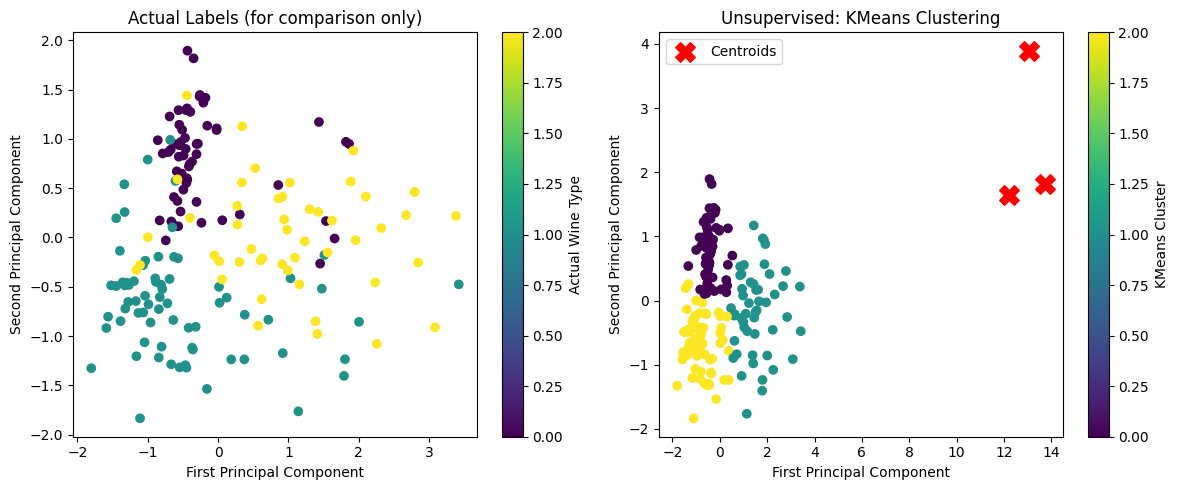

In [29]:
# VISUALIZATION (Unsupervised)
import matplotlib.pyplot as plt
# Plot the PCA-reduced data with KMeans clusters
plt.figure(figsize=(12, 5))

# Subplot 1: Actual wine types (for reference - but unsupervised doesn't use this)
plt.subplot(1, 2, 1)
scatter1 = plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=wine.target, cmap='viridis')
plt.colorbar(scatter1, label='Actual Wine Type')
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('Actual Labels (for comparison only)')

# Subplot 2: KMeans clustering result (unsupervised)
plt.subplot(1, 2, 2)
scatter2 = plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=cluster_labels, cmap='viridis')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], 
           marker='X', s=200, c='red', label='Centroids')
plt.colorbar(scatter2, label='KMeans Cluster')
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('Unsupervised: KMeans Clustering')
plt.legend()
plt.tight_layout()
plt.show()
